In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install shap xgboost imbalanced-learn -q
print("✅ Packages installed.")

Mounted at /content/drive
✅ Packages installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
print("✅ All libraries imported.")

✅ All libraries imported.


In [3]:
ae_path = "/content/drive/MyDrive/NHS and AE Dataset/merged_ae_dataset.csv"

if not os.path.exists(ae_path):
    raise FileNotFoundError(f"❌ File not found at:\n  {ae_path}")

# Load with no dedup yet so we can see all 25 columns
ae_df = pd.read_csv(ae_path, header=0)

print("✅ Dataset loaded.")
print(f"Shape: {ae_df.shape}")
print("\nAll columns:")
for i, c in enumerate(ae_df.columns):
    print(f"  [{i}] '{c}'")


✅ Dataset loaded.
Shape: (12236, 25)

All columns:
  [0] 'Period'
  [1] 'Org Code'
  [2] 'Parent Org'
  [3] 'Org name'
  [4] 'A&E attendances Type 1'
  [5] 'A&E attendances Type 2'
  [6] 'A&E attendances Other A&E Department'
  [7] 'A&E attendances Booked Appointments Type 1'
  [8] 'A&E attendances Booked Appointments Type 2'
  [9] 'A&E attendances Booked Appointments Other Department'
  [10] 'Attendances over 4hrs Type 1'
  [11] 'Attendances over 4hrs Type 2'
  [12] 'Attendances over 4hrs Other Department'
  [13] 'Attendances over 4hrs Booked Appointments Type 1'
  [14] 'Attendances over 4hrs Booked Appointments Type 2'
  [15] 'Attendances over 4hrs Booked Appointments Other Department'
  [16] 'Patients who have waited 4-12 hs from DTA to admission'
  [17] 'Patients who have waited 12+ hrs from DTA to admission'
  [18] 'Emergency admissions via A&E - Type 1'
  [19] 'Emergency admissions via A&E - Type 2'
  [20] 'Emergency admissions via A&E - Other A&E department'
  [21] 'Other emerge

In [4]:
# Drop the last column (index 24) which is the duplicate 'period'
ae_df = ae_df.iloc[:, :24]   # keep only first 24 columns

print("✅ Duplicate column dropped.")
print(f"Shape now: {ae_df.shape}")
print("Columns:")
for i, c in enumerate(ae_df.columns):
    print(f"  [{i}] '{c}'")


✅ Duplicate column dropped.
Shape now: (12236, 24)
Columns:
  [0] 'Period'
  [1] 'Org Code'
  [2] 'Parent Org'
  [3] 'Org name'
  [4] 'A&E attendances Type 1'
  [5] 'A&E attendances Type 2'
  [6] 'A&E attendances Other A&E Department'
  [7] 'A&E attendances Booked Appointments Type 1'
  [8] 'A&E attendances Booked Appointments Type 2'
  [9] 'A&E attendances Booked Appointments Other Department'
  [10] 'Attendances over 4hrs Type 1'
  [11] 'Attendances over 4hrs Type 2'
  [12] 'Attendances over 4hrs Other Department'
  [13] 'Attendances over 4hrs Booked Appointments Type 1'
  [14] 'Attendances over 4hrs Booked Appointments Type 2'
  [15] 'Attendances over 4hrs Booked Appointments Other Department'
  [16] 'Patients who have waited 4-12 hs from DTA to admission'
  [17] 'Patients who have waited 12+ hrs from DTA to admission'
  [18] 'Emergency admissions via A&E - Type 1'
  [19] 'Emergency admissions via A&E - Type 2'
  [20] 'Emergency admissions via A&E - Other A&E department'
  [21] 'Oth

In [5]:
COL_PERIOD     = "Period"
COL_TRUST_ID   = "Org Code"
COL_TRUST_NAME = "Org name"
COL_PARENT     = "Parent Org"

# Attendance columns
ATT_COLS = [
    "A&E attendances Type 1",
    "A&E attendances Type 2",
    "A&E attendances Other A&E Department",
]

# Over-4-hour breach columns (exact names from your file)
OVER4_COLS = [
    "Attendances over 4hrs Type 1",
    "Attendances over 4hrs Type 2",
    "Attendances over 4hrs Other Department",   # ← exact name in your file
]

# Extra clinically useful columns
EXTRA_COLS = [
    "Patients who have waited 4-12 hs from DTA to admission",
    "Patients who have waited 12+ hrs from DTA to admission",
    "Emergency admissions via A&E - Type 1",
    "Emergency admissions via A&E - Type 2",
    "Emergency admissions via A&E - Other A&E department",
    "Other emergency admissions",
]

# Verify all columns exist
print("Checking columns exist...")
all_needed = [COL_PERIOD, COL_TRUST_ID] + ATT_COLS + OVER4_COLS + EXTRA_COLS
for col in all_needed:
    status = "✅" if col in ae_df.columns else "❌ MISSING"
    print(f"  {status}  '{col}'")

Checking columns exist...
  ✅  'Period'
  ✅  'Org Code'
  ✅  'A&E attendances Type 1'
  ✅  'A&E attendances Type 2'
  ✅  'A&E attendances Other A&E Department'
  ✅  'Attendances over 4hrs Type 1'
  ✅  'Attendances over 4hrs Type 2'
  ✅  'Attendances over 4hrs Other Department'
  ✅  'Patients who have waited 4-12 hs from DTA to admission'
  ✅  'Patients who have waited 12+ hrs from DTA to admission'
  ✅  'Emergency admissions via A&E - Type 1'
  ✅  'Emergency admissions via A&E - Type 2'
  ✅  'Emergency admissions via A&E - Other A&E department'
  ✅  'Other emergency admissions'


In [6]:
# Extract the date part after "MSitAE-" and before any suffix
# e.g. 'MSitAE-JANUARY-2021' → 'JANUARY-2021' → datetime

def parse_nhs_period(val):
    """Parse NHS period strings like 'MSitAE-JANUARY-2021' or 'TOTAL'."""
    if not isinstance(val, str):
        return pd.NaT
    val = val.strip().upper()
    # Skip non-date rows like 'TOTAL'
    if val == "TOTAL" or not val.startswith("MSITAE-"):
        return pd.NaT
    # Remove prefix → 'JANUARY-2021'
    date_part = val.replace("MSITAE-", "")
    try:
        return pd.to_datetime(date_part, format="%B-%Y")
    except Exception:
        return pd.NaT

ae_df["date"] = ae_df[COL_PERIOD].apply(parse_nhs_period)

n_bad = ae_df["date"].isnull().sum()
print(f"Rows where date failed to parse: {n_bad} / {len(ae_df)}")
if n_bad > 0:
    print("Unparsed sample:", ae_df.loc[ae_df["date"].isnull(), COL_PERIOD].unique()[:5])

# Drop non-parseable rows (e.g. 'TOTAL' summary rows)
before = len(ae_df)
ae_df = ae_df.dropna(subset=[COL_TRUST_ID, "date"])
print(f"Dropped {before - len(ae_df)} rows (TOTAL/header rows). Remaining: {len(ae_df)}")

# Also add year/month from parsed date (overwrite the existing year/month cols
# which may have come from the raw file and could be unreliable)
ae_df["year"]  = ae_df["date"].dt.year
ae_df["month"] = ae_df["date"].dt.month

print("\nDate range in dataset:")
print(f"  From: {ae_df['date'].min().strftime('%B %Y')}")
print(f"  To:   {ae_df['date'].max().strftime('%B %Y')}")
print(f"\nSample parsed dates:")
print(ae_df[["Period", "date", "year", "month"]].head(10))

Rows where date failed to parse: 60 / 12236
Unparsed sample: ['TOTAL' 'Total' 'TOTAl' 'Total ']
Dropped 60 rows (TOTAL/header rows). Remaining: 12176

Date range in dataset:
  From: January 2021
  To:   December 2025

Sample parsed dates:
                Period       date  year  month
0  MSitAE-JANUARY-2021 2021-01-01  2021      1
1  MSitAE-JANUARY-2021 2021-01-01  2021      1
2  MSitAE-JANUARY-2021 2021-01-01  2021      1
3  MSitAE-JANUARY-2021 2021-01-01  2021      1
4  MSitAE-JANUARY-2021 2021-01-01  2021      1
5  MSitAE-JANUARY-2021 2021-01-01  2021      1
6  MSitAE-JANUARY-2021 2021-01-01  2021      1
7  MSitAE-JANUARY-2021 2021-01-01  2021      1
8  MSitAE-JANUARY-2021 2021-01-01  2021      1
9  MSitAE-JANUARY-2021 2021-01-01  2021      1


In [7]:
for col in ATT_COLS + OVER4_COLS + EXTRA_COLS:
    ae_df[col] = pd.to_numeric(ae_df[col], errors="coerce")

ae_df["total_attendances"] = ae_df[ATT_COLS].sum(axis=1, min_count=1)
ae_df["total_over_4hr"]    = ae_df[OVER4_COLS].sum(axis=1, min_count=1)
ae_df["total_admissions"]  = ae_df[
    ["Emergency admissions via A&E - Type 1",
     "Emergency admissions via A&E - Type 2",
     "Emergency admissions via A&E - Other A&E department",
     "Other emergency admissions"]
].sum(axis=1, min_count=1)

ae_df["breach_rate"] = np.where(
    ae_df["total_attendances"] > 0,
    ae_df["total_over_4hr"] / ae_df["total_attendances"],
    np.nan
)

ae_df = ae_df.dropna(subset=["breach_rate"])
ae_df["breach"] = (ae_df["breach_rate"] > 0.05).astype(int)

print("✅ Target variable created.")
print(ae_df["breach_rate"].describe().round(4))
print(f"\nClass distribution (raw counts):")
print(ae_df["breach"].value_counts())
print(f"\nClass distribution (%):")
print(ae_df["breach"].value_counts(normalize=True).round(3))

✅ Target variable created.
count    11403.0000
mean         0.1870
std          0.1545
min          0.0000
25%          0.0080
50%          0.2171
75%          0.3140
max          0.6035
Name: breach_rate, dtype: float64

Class distribution (raw counts):
breach
1    7429
0    3974
Name: count, dtype: int64

Class distribution (%):
breach
1    0.651
0    0.349
Name: proportion, dtype: float64


In [8]:
ae_df = ae_df.sort_values([COL_TRUST_ID, "date"]).reset_index(drop=True)

# Time features
ae_df["month"]     = ae_df["date"].dt.month
ae_df["year"]      = ae_df["date"].dt.year
ae_df["quarter"]   = ae_df["date"].dt.quarter
ae_df["is_winter"] = ae_df["month"].isin([12, 1, 2]).astype(int)
ae_df["is_summer"] = ae_df["month"].isin([6, 7, 8]).astype(int)

# Rolling 3-month average per trust
ae_df["rolling_3m_attend"] = (
    ae_df.groupby(COL_TRUST_ID)["total_attendances"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)
ae_df["rolling_3m_over4"] = (
    ae_df.groupby(COL_TRUST_ID)["total_over_4hr"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Lag features — previous month's breach rate for this trust
ae_df["lag1_breach_rate"] = (
    ae_df.groupby(COL_TRUST_ID)["breach_rate"]
    .transform(lambda x: x.shift(1))
)
ae_df["lag2_breach_rate"] = (
    ae_df.groupby(COL_TRUST_ID)["breach_rate"]
    .transform(lambda x: x.shift(2))
)

# Type 1 proportion (major A&E — most severe cases)
ae_df["type1_att_prop"] = (
    ae_df["A&E attendances Type 1"] /
    ae_df["total_attendances"].replace(0, np.nan)
)

# Admission pressure ratio
ae_df["admission_pressure"] = (
    ae_df["total_admissions"] /
    ae_df["total_attendances"].replace(0, np.nan)
)

# Long wait ratio (12+ hour waits — most severe)
ae_df["long_wait_ratio"] = (
    ae_df["Patients who have waited 12+ hrs from DTA to admission"] /
    ae_df["total_attendances"].replace(0, np.nan)
)

# Encode trust as numeric ID
le = LabelEncoder()
ae_df["trust_id_enc"] = le.fit_transform(ae_df[COL_TRUST_ID].astype(str))

print("✅ Feature engineering complete.")
print(ae_df[["date", "month", "year", "is_winter", "lag1_breach_rate",
             "type1_att_prop", "breach"]].head(10))

✅ Feature engineering complete.
        date  month  year  is_winter  lag1_breach_rate  type1_att_prop  breach
0 2025-03-01      3  2025          0               NaN             0.0       1
1 2025-04-01      4  2025          0          0.397718             0.0       1
2 2025-05-01      5  2025          0          0.228597             0.0       1
3 2025-06-01      6  2025          0          0.227967             0.0       1
4 2025-07-01      7  2025          0          0.193514             0.0       1
5 2025-08-01      8  2025          0          0.213669             0.0       1
6 2025-09-01      9  2025          0          0.237718             0.0       1
7 2021-01-01      1  2021          1               NaN             0.0       0
8 2021-02-01      2  2021          1          0.000000             0.0       0
9 2021-03-01      3  2021          0          0.000000             0.0       0


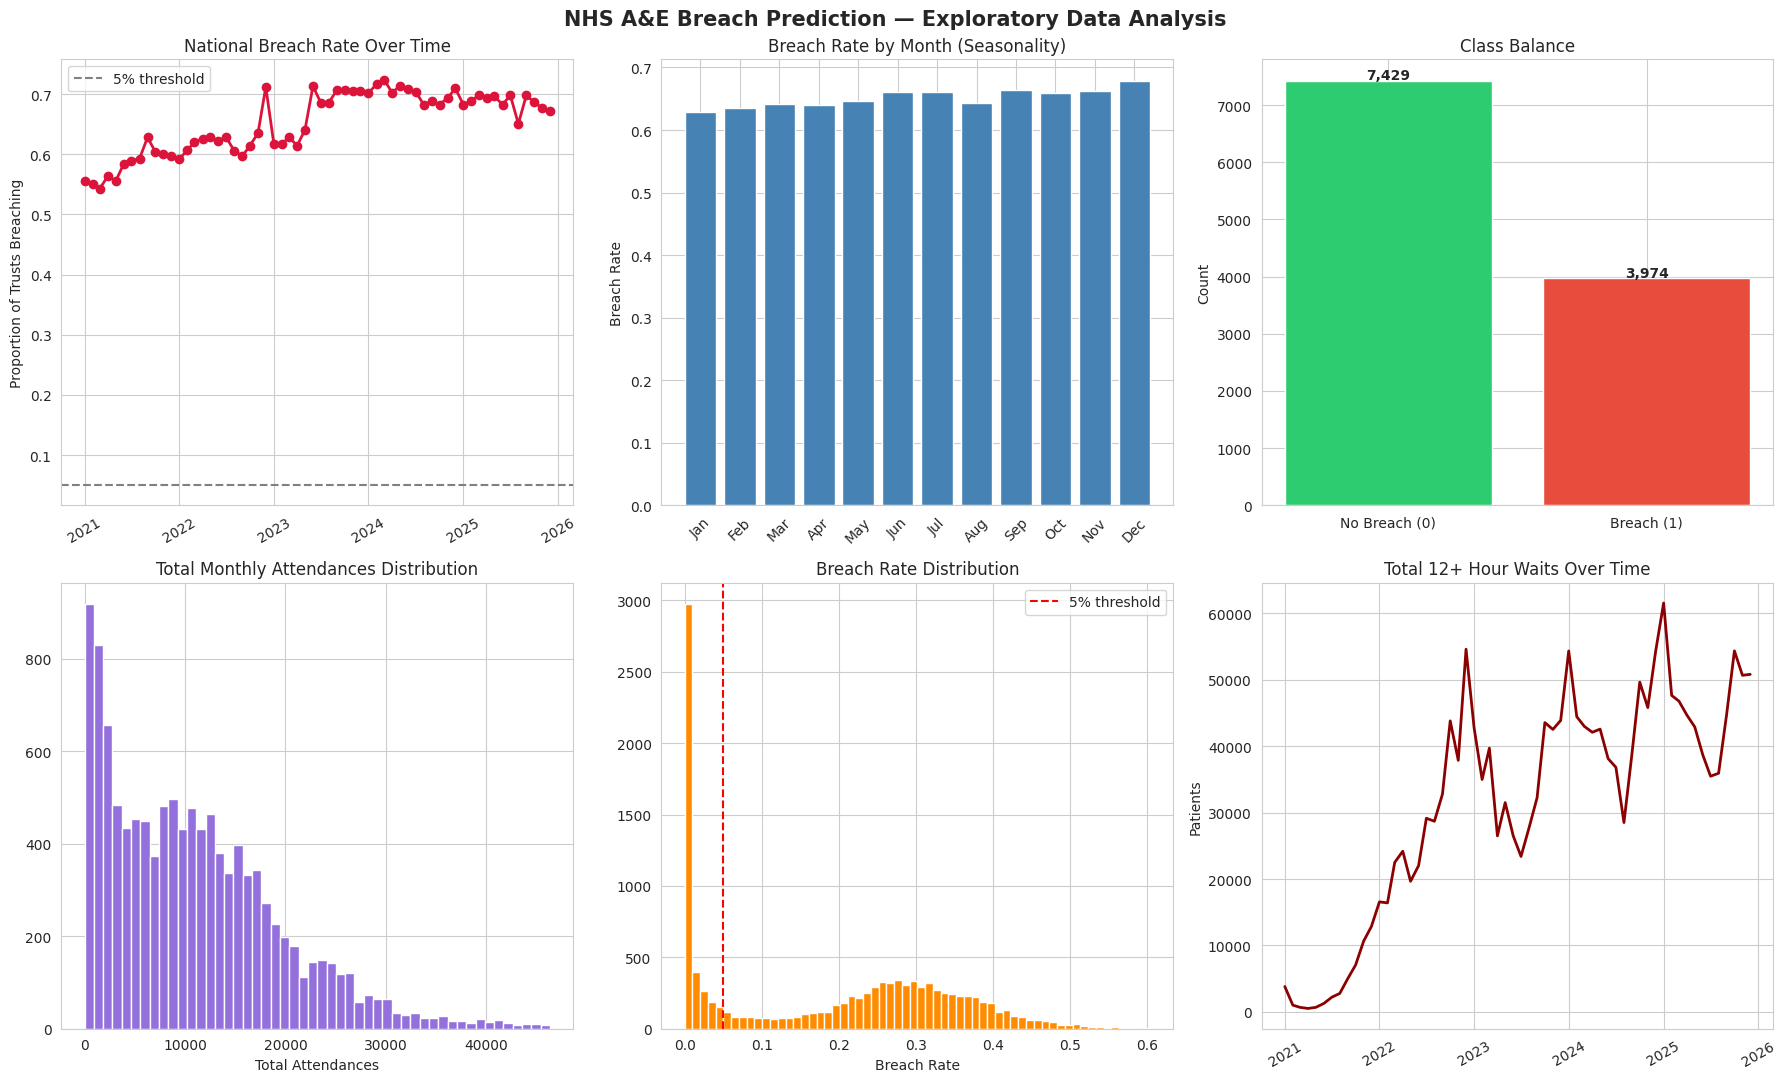

✅ EDA plots saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("NHS A&E Breach Prediction — Exploratory Data Analysis",
             fontsize=15, fontweight="bold")

# 1. Breach rate over time (national average)
monthly = ae_df.groupby("date")["breach"].mean().reset_index()
axes[0,0].plot(monthly["date"], monthly["breach"], marker="o",
               color="crimson", linewidth=2)
axes[0,0].axhline(0.05, color="gray", linestyle="--", label="5% threshold")
axes[0,0].set_title("National Breach Rate Over Time")
axes[0,0].set_ylabel("Proportion of Trusts Breaching")
axes[0,0].tick_params(axis="x", rotation=30)
axes[0,0].legend()

# 2. Seasonality
seasonal = ae_df.groupby("month")["breach"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0,1].bar(seasonal.index, seasonal.values, color="steelblue")
axes[0,1].set_title("Breach Rate by Month (Seasonality)")
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_labels, rotation=45)
axes[0,1].set_ylabel("Breach Rate")

# 3. Class balance
counts = ae_df["breach"].value_counts()
axes[0,2].bar(["No Breach (0)", "Breach (1)"], counts.values,
              color=["#2ecc71","#e74c3c"])
for i, v in enumerate(counts.values):
    axes[0,2].text(i, v + 20, f"{v:,}", ha="center", fontweight="bold")
axes[0,2].set_title("Class Balance")
axes[0,2].set_ylabel("Count")

# 4. Total attendances distribution
axes[1,0].hist(ae_df["total_attendances"].dropna(), bins=50,
               color="mediumpurple", edgecolor="white")
axes[1,0].set_title("Total Monthly Attendances Distribution")
axes[1,0].set_xlabel("Total Attendances")

# 5. Breach rate distribution
axes[1,1].hist(ae_df["breach_rate"].dropna(), bins=60,
               color="darkorange", edgecolor="white")
axes[1,1].axvline(0.05, color="red", linestyle="--", label="5% threshold")
axes[1,1].set_title("Breach Rate Distribution")
axes[1,1].set_xlabel("Breach Rate")
axes[1,1].legend()

# 6. 12+ hour waits over time
long_waits = ae_df.groupby("date")["Patients who have waited 12+ hrs from DTA to admission"].sum()
axes[1,2].plot(long_waits.index, long_waits.values, color="darkred", linewidth=2)
axes[1,2].set_title("Total 12+ Hour Waits Over Time")
axes[1,2].set_ylabel("Patients")
axes[1,2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/eda_plots.png", dpi=150)
plt.show()
print("✅ EDA plots saved.")





In [10]:

FEATURE_COLS = [
    # Time
    "month", "year", "quarter", "is_winter", "is_summer",
    # Raw attendance volumes
    "A&E attendances Type 1",
    "A&E attendances Type 2",
    "A&E attendances Other A&E Department",
    "total_attendances",
    # Over 4hr counts
    "Attendances over 4hrs Type 1",
    "Attendances over 4hrs Type 2",
    "Attendances over 4hrs Other Department",
    "total_over_4hr",
    # Admissions
    "total_admissions",
    "Patients who have waited 4-12 hs from DTA to admission",
    "Patients who have waited 12+ hrs from DTA to admission",
    # Engineered
    "rolling_3m_attend",
    "rolling_3m_over4",
    "lag1_breach_rate",
    "lag2_breach_rate",
    "type1_att_prop",
    "admission_pressure",
    "long_wait_ratio",
    "trust_id_enc",
]

# Safety check — only keep cols that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in ae_df.columns]
print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)

X = ae_df[FEATURE_COLS].copy()
y = ae_df["breach"].copy()

# Drop rows where any feature or target is NaN
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

print(f"\n✅ Final modelling dataset: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Class distribution:\n{y.value_counts()}")

Using 24 features:
['month', 'year', 'quarter', 'is_winter', 'is_summer', 'A&E attendances Type 1', 'A&E attendances Type 2', 'A&E attendances Other A&E Department', 'total_attendances', 'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2', 'Attendances over 4hrs Other Department', 'total_over_4hr', 'total_admissions', 'Patients who have waited 4-12 hs from DTA to admission', 'Patients who have waited 12+ hrs from DTA to admission', 'rolling_3m_attend', 'rolling_3m_over4', 'lag1_breach_rate', 'lag2_breach_rate', 'type1_att_prop', 'admission_pressure', 'long_wait_ratio', 'trust_id_enc']

✅ Final modelling dataset: 10970 rows × 24 features
Class distribution:
breach
1    7201
0    3769
Name: count, dtype: int64


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Before SMOTE: {dict(y.value_counts())}")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)
print(f"After  SMOTE: {dict(pd.Series(y_res).value_counts())}")


Before SMOTE: {1: np.int64(7201), 0: np.int64(3769)}
After  SMOTE: {1: np.int64(7201), 0: np.int64(7201)}


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, learning_rate=0.05,
                                          use_label_encoder=False,
                                          eval_metric="logloss", random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=7),
}



In [13]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print("🏋 Training with 10-fold stratified cross-validation...\n")
for name, model in models.items():
    f1  = cross_val_score(model, X_res, y_res, cv=skf, scoring="f1",        n_jobs=-1)
    auc = cross_val_score(model, X_res, y_res, cv=skf, scoring="roc_auc",   n_jobs=-1)
    rec = cross_val_score(model, X_res, y_res, cv=skf, scoring="recall",    n_jobs=-1)
    pre = cross_val_score(model, X_res, y_res, cv=skf, scoring="precision", n_jobs=-1)
    results[name] = {
        "F1":        round(f1.mean(),  4),
        "F1 Std":    round(f1.std(),   4),
        "ROC-AUC":   round(auc.mean(), 4),
        "Recall":    round(rec.mean(), 4),
        "Precision": round(pre.mean(), 4),
    }
    print(f"  {name:25s} | F1={f1.mean():.4f} ± {f1.std():.4f} | AUC={auc.mean():.4f} | Recall={rec.mean():.4f}")

results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
print("\n📊 Full Model Comparison:")
display(results_df)

🏋 Training with 10-fold stratified cross-validation...

  Logistic Regression       | F1=0.9908 ± 0.0018 | AUC=0.9997 | Recall=0.9864
  Decision Tree             | F1=0.9940 ± 0.0025 | AUC=0.9944 | Recall=0.9926
  Random Forest             | F1=0.9961 ± 0.0022 | AUC=0.9999 | Recall=0.9946
  XGBoost                   | F1=0.9971 ± 0.0015 | AUC=1.0000 | Recall=0.9963
  KNN                       | F1=0.9828 ± 0.0037 | AUC=0.9960 | Recall=0.9688

📊 Full Model Comparison:


,F1,F1 Std,ROC-AUC,Recall,Precision
XGBoost,0.9971,0.0015,1.0000,0.9963,0.9981
Random Forest,0.9961,0.0022,0.9999,0.9946,0.9976
Decision Tree,0.9940,0.0025,0.9944,0.9926,0.9954
Logistic Regression,0.9908,0.0018,0.9997,0.9864,0.9952
KNN,0.9828,0.0037,0.9960,0.9688,0.9973


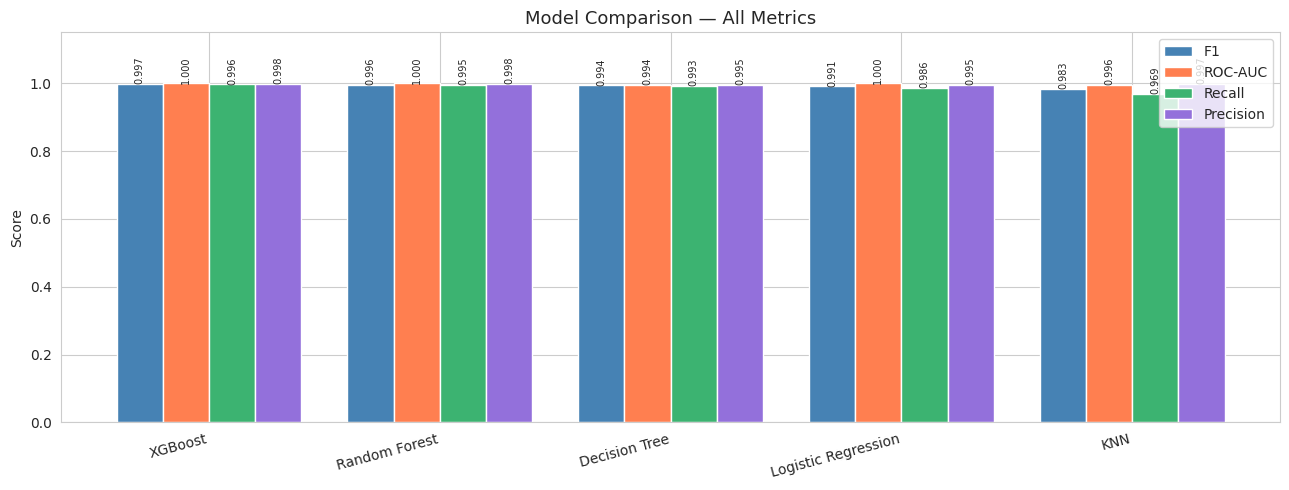

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_df))
w = 0.2
metrics = ["F1", "ROC-AUC", "Recall", "Precision"]
colors  = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * w, results_df[metric], w, label=metric, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", fontsize=7, rotation=90)

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(results_df.index, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.set_title("Model Comparison — All Metrics", fontsize=13)
ax.legend(loc="upper right")
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/model_comparison.png", dpi=150)
plt.show()


  FINAL MODEL: Random Forest — Hold-Out Test Set
  Accuracy:  0.9948
  Precision: 0.9965
  Recall:    0.9931
  F1-Score:  0.9948
  ROC-AUC:   0.9999

              precision    recall  f1-score   support

   No Breach       0.99      1.00      0.99      1441
      Breach       1.00      0.99      0.99      1440

    accuracy                           0.99      2881
   macro avg       0.99      0.99      0.99      2881
weighted avg       0.99      0.99      0.99      2881



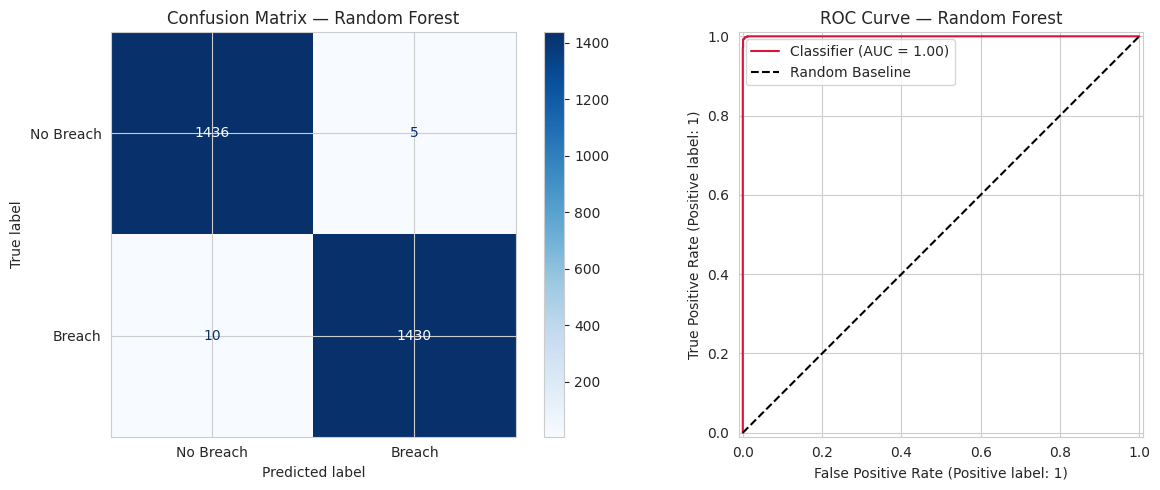

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  FINAL MODEL: Random Forest — Hold-Out Test Set")
print("=" * 55)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Breach", "Breach"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Breach", "Breach"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix — Random Forest")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color="crimson")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Baseline")
axes[1].set_title("ROC Curve — Random Forest")
axes[1].legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/final_evaluation.png", dpi=150)
plt.show()

🔍 Running SHAP (may take 1–2 minutes)...


<Figure size 1000x700 with 0 Axes>

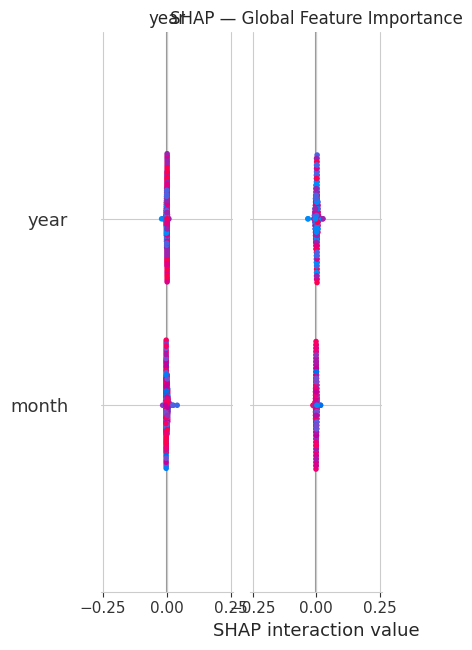

<Figure size 1000x800 with 0 Axes>

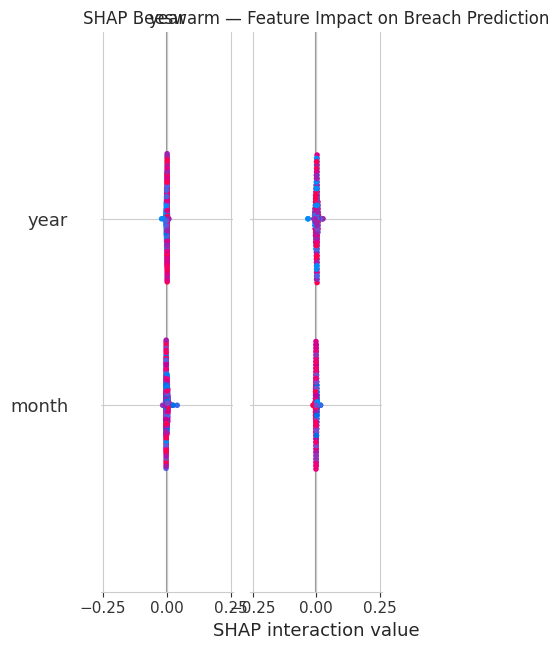

✅ SHAP complete.


In [16]:
print("🔍 Running SHAP (may take 1–2 minutes)...")

explainer   = shap.TreeExplainer(best_model)
sample_size = min(300, X_test.shape[0])
shap_sample = X_test[:sample_size]
shap_values = explainer.shap_values(shap_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Global bar — overall importance
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, shap_sample, feature_names=FEATURE_COLS,
                  plot_type="bar", show=False)
plt.title("SHAP — Global Feature Importance")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/shap_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Beeswarm — direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, shap_sample, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Beeswarm — Feature Impact on Breach Prediction")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/shap_beeswarm.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP complete.")



📐 Fairness / Subgroup Analysis

Performance by Season:
  Season       |     n |     F1 | Recall | Precision
  ---------------------------------------------
  Winter       |   515 | 0.9985 | 0.9971 |    1.0000
  Non-Winter   |  1679 | 0.9982 | 0.9991 |    0.9973

Performance by Year:
  Year   |     n |     F1 | Recall | Precision
  ------------------------------------------
    2021 |   367 | 0.9953 | 1.0000 |    0.9907
    2022 |   465 | 1.0000 | 1.0000 |    1.0000
    2023 |   449 | 1.0000 | 1.0000 |    1.0000
    2024 |   483 | 1.0000 | 1.0000 |    1.0000
    2025 |   430 | 0.9949 | 0.9932 |    0.9966


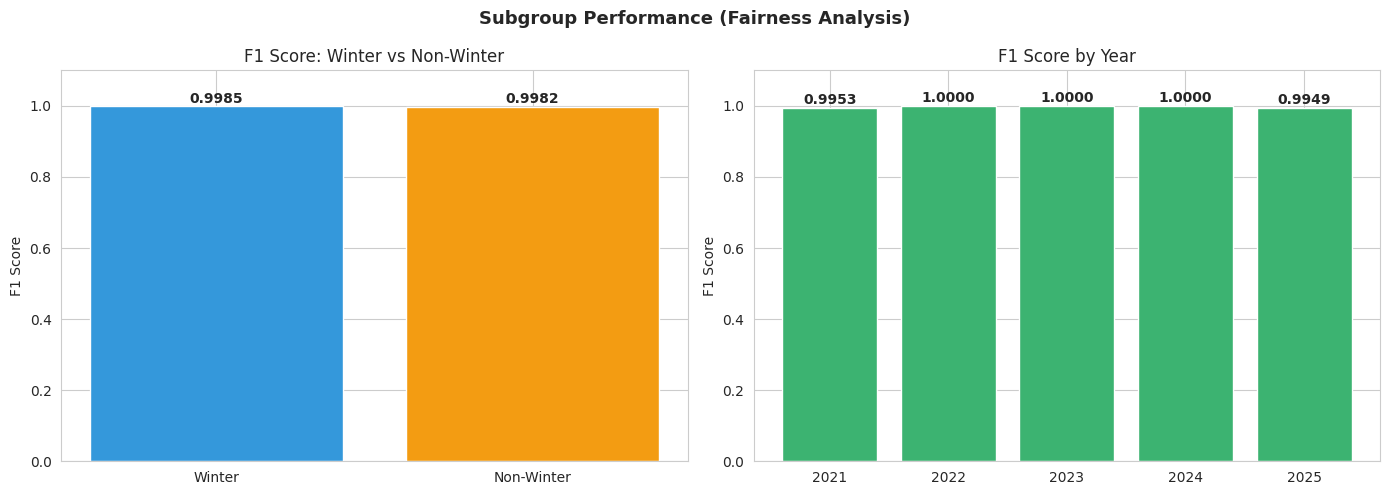

✅ Fairness analysis complete.


In [17]:
print("\n📐 Fairness / Subgroup Analysis\n")

# Use unsmoted data to preserve real metadata
X_raw_tr, X_raw_te, y_raw_tr, y_raw_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_raw_te_scaled = scaler.transform(X_raw_te)
y_raw_pred      = best_model.predict(X_raw_te_scaled)

meta = X_raw_te.copy().reset_index(drop=True)
meta["y_true"] = y_raw_te.values
meta["y_pred"] = y_raw_pred

# By season
print("Performance by Season:")
print(f"  {'Season':12s} | {'n':>5} | {'F1':>6} | {'Recall':>6} | {'Precision':>9}")
print("  " + "-" * 45)
season_rows = []
for val, label in [(1, "Winter"), (0, "Non-Winter")]:
    sub = meta[meta["is_winter"] == val]
    if len(sub) > 5:
        f1_s  = f1_score(sub["y_true"], sub["y_pred"], zero_division=0)
        rec_s = recall_score(sub["y_true"], sub["y_pred"], zero_division=0)
        pre_s = precision_score(sub["y_true"], sub["y_pred"], zero_division=0)
        season_rows.append((label, len(sub), f1_s, rec_s, pre_s))
        print(f"  {label:12s} | {len(sub):>5} | {f1_s:>6.4f} | {rec_s:>6.4f} | {pre_s:>9.4f}")

# By year
print("\nPerformance by Year:")
print(f"  {'Year':6s} | {'n':>5} | {'F1':>6} | {'Recall':>6} | {'Precision':>9}")
print("  " + "-" * 42)
year_rows = []
for yr in sorted(meta["year"].unique()):
    sub = meta[meta["year"] == yr]
    if len(sub) > 5:
        f1_y  = f1_score(sub["y_true"], sub["y_pred"], zero_division=0)
        rec_y = recall_score(sub["y_true"], sub["y_pred"], zero_division=0)
        pre_y = precision_score(sub["y_true"], sub["y_pred"], zero_division=0)
        year_rows.append((int(yr), len(sub), f1_y, rec_y, pre_y))
        print(f"  {int(yr):6d} | {len(sub):>5} | {f1_y:>6.4f} | {rec_y:>6.4f} | {pre_y:>9.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if season_rows:
    s_labels = [r[0] for r in season_rows]
    s_f1s    = [r[2] for r in season_rows]
    axes[0].bar(s_labels, s_f1s, color=["#3498db","#f39c12"])
    for i, v in enumerate(s_f1s):
        axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")
    axes[0].set_title("F1 Score: Winter vs Non-Winter")
    axes[0].set_ylabel("F1 Score")
    axes[0].set_ylim(0, 1.1)

if year_rows:
    y_labels = [str(r[0]) for r in year_rows]
    y_f1s    = [r[2] for r in year_rows]
    axes[1].bar(y_labels, y_f1s, color="mediumseagreen")
    for i, v in enumerate(y_f1s):
        axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")
    axes[1].set_title("F1 Score by Year")
    axes[1].set_ylabel("F1 Score")
    axes[1].set_ylim(0, 1.1)

plt.suptitle("Subgroup Performance (Fairness Analysis)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/fairness_analysis.png", dpi=150)
plt.show()
print("✅ Fairness analysis complete.")


In [18]:
SAVE = "/content/drive/MyDrive/NHS and AE Dataset"

joblib.dump(best_model, f"{SAVE}/best_model_rf.pkl")
joblib.dump(scaler,     f"{SAVE}/scaler.pkl")
results_df.to_csv(f"{SAVE}/model_results.csv")

print(f"✅ Model saved:   {SAVE}/best_model_rf.pkl")
print(f"✅ Scaler saved:  {SAVE}/scaler.pkl")
print(f"✅ Results saved: {SAVE}/model_results.csv")

print("\n" + "=" * 55)
print("  🎉 PIPELINE COMPLETE!")
print("=" * 55)
print("\nFiles in your Google Drive (NHS and AE Dataset folder):")
for f in ["eda_plots.png","model_comparison.png","final_evaluation.png",
          "shap_importance.png","shap_beeswarm.png","fairness_analysis.png",
          "best_model_rf.pkl","scaler.pkl","model_results.csv"]:
    print(f"  📁 {f}")

✅ Model saved:   /content/drive/MyDrive/NHS and AE Dataset/best_model_rf.pkl
✅ Scaler saved:  /content/drive/MyDrive/NHS and AE Dataset/scaler.pkl
✅ Results saved: /content/drive/MyDrive/NHS and AE Dataset/model_results.csv

  🎉 PIPELINE COMPLETE!

Files in your Google Drive (NHS and AE Dataset folder):
  📁 eda_plots.png
  📁 model_comparison.png
  📁 final_evaluation.png
  📁 shap_importance.png
  📁 shap_beeswarm.png
  📁 fairness_analysis.png
  📁 best_model_rf.pkl
  📁 scaler.pkl
  📁 model_results.csv


  BEST MODEL: XGBoost — Hold-Out Test Set
  Accuracy:  0.9986
  Precision: 0.9993
  Recall:    0.9979
  F1-Score:  0.9986
  ROC-AUC:   1.0000

              precision    recall  f1-score   support

   No Breach       1.00      1.00      1.00      1441
      Breach       1.00      1.00      1.00      1440

    accuracy                           1.00      2881
   macro avg       1.00      1.00      1.00      2881
weighted avg       1.00      1.00      1.00      2881



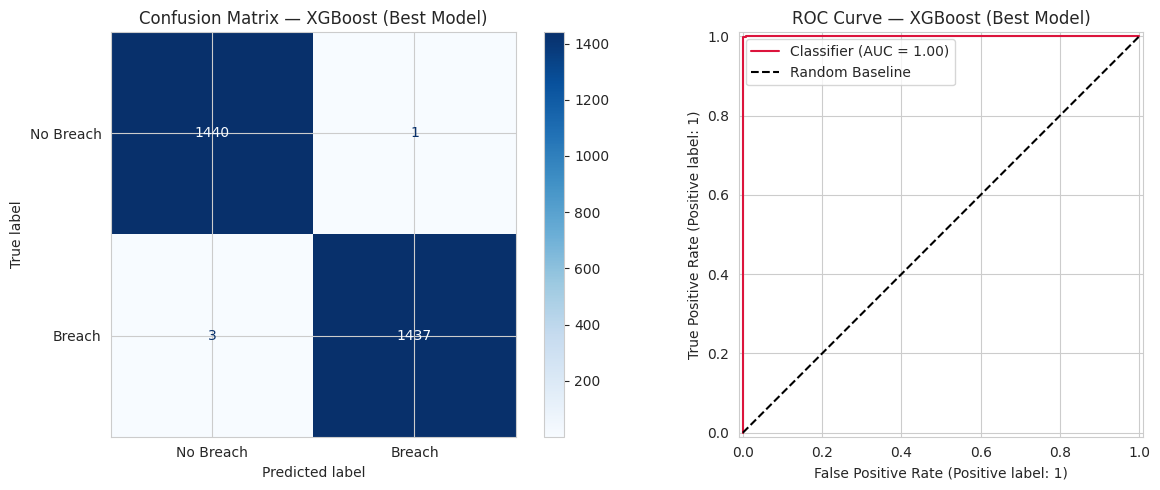

🔍 Running SHAP on XGBoost...


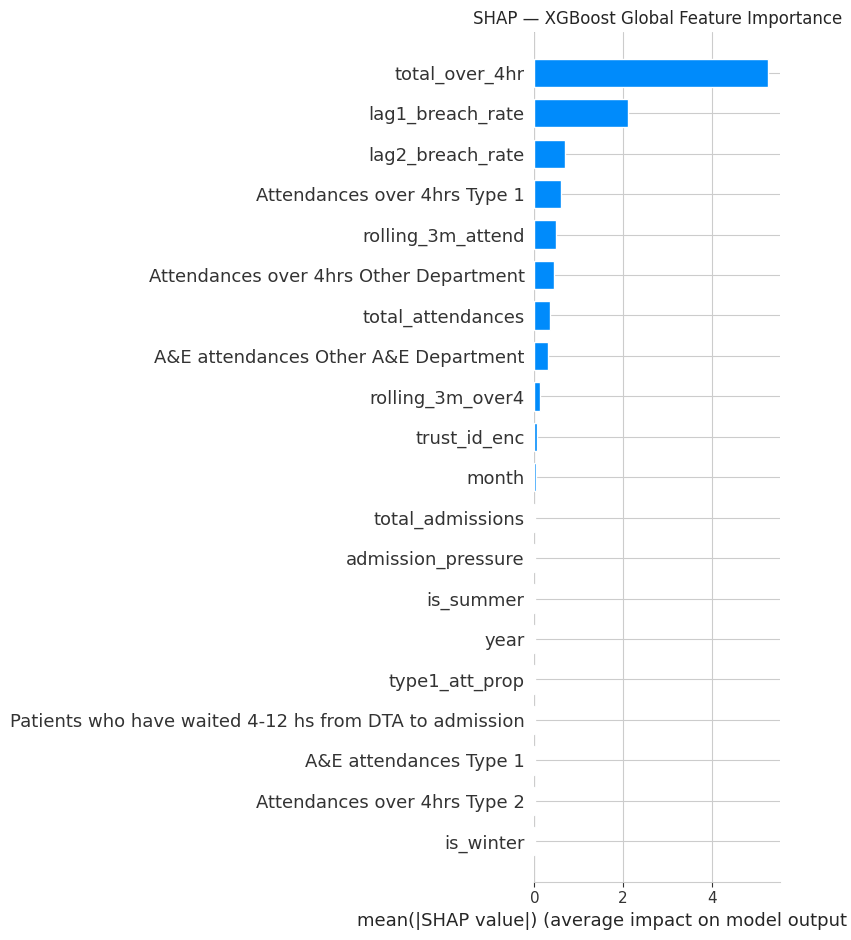

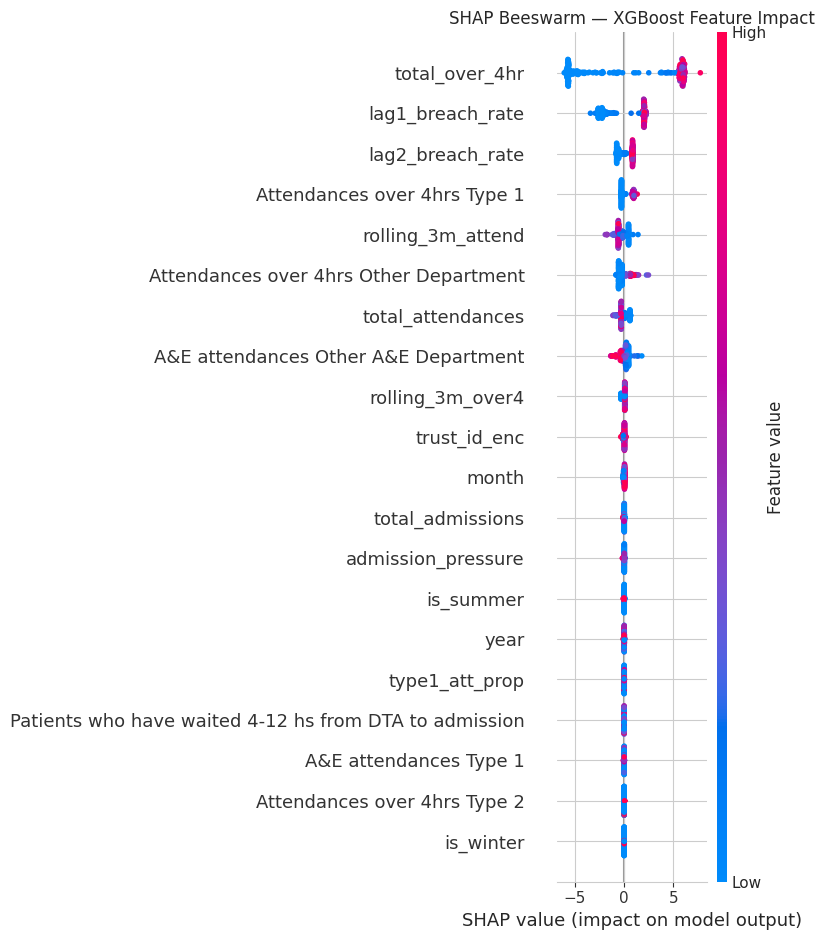

✅ XGBoost model saved to /content/drive/MyDrive/NHS and AE Dataset/best_model_xgb.pkl


In [19]:
# BEST MODEL: XGBoost — Final Hold-Out Evaluation
# ─────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt
import shap, joblib

# Train XGBoost on same train split
best_xgb = XGBClassifier(n_estimators=200, learning_rate=0.05,
                          use_label_encoder=False,
                          eval_metric='logloss', random_state=42)
best_xgb.fit(X_train, y_train)

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  BEST MODEL: XGBoost — Hold-Out Test Set")
print("=" * 55)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=["No Breach", "Breach"]))

# Confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=["No Breach", "Breach"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix — XGBoost (Best Model)")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb,
                                  ax=axes[1], color="crimson")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Baseline")
axes[1].set_title("ROC Curve — XGBoost (Best Model)")
axes[1].legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/xgboost_final_evaluation.png", dpi=150)
plt.show()

# SHAP for XGBoost
print("🔍 Running SHAP on XGBoost...")
explainer_xgb   = shap.TreeExplainer(best_xgb)
shap_sample_xgb = X_test[:300]
shap_values_xgb = explainer_xgb.shap_values(shap_sample_xgb)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_xgb, shap_sample_xgb,
                  feature_names=FEATURE_COLS,
                  plot_type="bar", show=False)
plt.title("SHAP — XGBoost Global Feature Importance")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/xgboost_shap_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_xgb, shap_sample_xgb,
                  feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Beeswarm — XGBoost Feature Impact")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NHS and AE Dataset/xgboost_shap_beeswarm.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Save XGBoost as best model
SAVE = "/content/drive/MyDrive/NHS and AE Dataset"
joblib.dump(best_xgb, f"{SAVE}/best_model_xgb.pkl")
print(f"✅ XGBoost model saved to {SAVE}/best_model_xgb.pkl")